<a href="https://colab.research.google.com/github/christy5165/RFM-Analysis-with-Gemini-Ai/blob/main/RFM-Analysis-with-Gemini-Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Load the dataset directly from the UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
df = pd.read_excel(url)

# Quick look at the data
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# 1. Drop rows with no Customer ID
df.dropna(subset=['Customer ID'], inplace=True)

# 2. Remove cancellations
df = df[~df['Invoice'].str.contains('C', na=False)]

# 3. Create a 'TotalSum' column
df['TotalSum'] = df['Quantity'] * df['Price']

print("Data Cleaning Complete.")

Data Cleaning Complete.


In [4]:
# Create the RFM Table for Visualization
# We use the max date in the dataset as the 'snapshot' point
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'count',
    'TotalSum': 'sum'
})

# Rename for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSum': 'MonetaryValue'
}, inplace=True)

# Create the R_Score for the Heatmap we planned
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

print("RFM Table created! Now you can run the Matplotlib cell.")

RFM Table created! Now you can run the Matplotlib cell.


In [6]:
import google.generativeai as genai
from google.colab import userdata

# 1. Setup API (Use Colab Secrets for 'GOOGLE_API_KEY')
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))
model = genai.GenerativeModel('gemini-1.5-flash')

def get_ai_strategy(segment_name, avg_spend):
    prompt = f"""
    You are a Senior Marketing Strategist.
    We have a customer segment labeled '{segment_name}' with an average spend of ${avg_spend:.2f}.
    1. Define a 1-sentence marketing goal for this group.
    2. Write a catchy email subject line for them.
    """
    response = model.generate_content(prompt)
    return response.text

# 2. Apply to our top segments
for segment in ['Champions', 'At Risk']:
    # Assuming 'segment_analysis' is your summary table from the previous step
    avg_m = segment_analysis.loc[segment, 'MonetaryValue']
    print(f"--- Strategy for {segment} ---")
    print(get_ai_strategy(segment, avg_m))

NameError: name 'segment_analysis' is not defined

In [11]:
import google.generativeai as genai
from google.colab import userdata

# 1. Setup API (Make sure the Secret name on the left is GOOGLE_API_KEY)
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))
model = genai.GenerativeModel('gemini-1.5-flash-latest')

def get_ai_strategy(segment_name):
    prompt = f"""
    You are a Senior Marketing Strategist.
    We have a customer segment labeled '{segment_name}'.
    1. Define a 1-sentence marketing goal for this group.
    2. Write a catchy email subject line for them.
    """
    response = model.generate_content(prompt)
    return response.text

# 2. Test it out
for segment in ['Champions', 'At Risk']:
    print(f"--- Strategy for {segment} ---")
    print(get_ai_strategy(segment))

--- Strategy for Champions ---


NotFound: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

In [10]:
import google.generativeai as genai
from google.colab import userdata

# This line "calls" the secret key from your safe
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))

# This line asks Gemini a simple question
model = genai.GenerativeModel('gemini-1.5-flash-latest')
response = model.generate_content("Say 'Hello, I am working!'")

print(response.text)

NotFound: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

In [12]:
import google.generativeai as genai
from google.colab import userdata

# 1. Setup API
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))

# 2. Initialize the model (using the 'latest' tag fixes the 404 error)
model = genai.GenerativeModel('gemini-1.5-flash-latest')

# 3. Test the connection
try:
    response = model.generate_content("Say 'Hello, your API is officially connected!'")
    print(response.text)
except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


In [13]:
# Create the RFM Table for Visualization
# We use the max date in the dataset as the 'snapshot' point
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'count',
    'TotalSum': 'sum'
})

# Rename for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSum': 'MonetaryValue'
}, inplace=True)

# Create the R_Score for the Heatmap we planned
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

print("RFM Table created! Now you can run the Matplotlib cell.")

RFM Table created! Now you can run the Matplotlib cell.


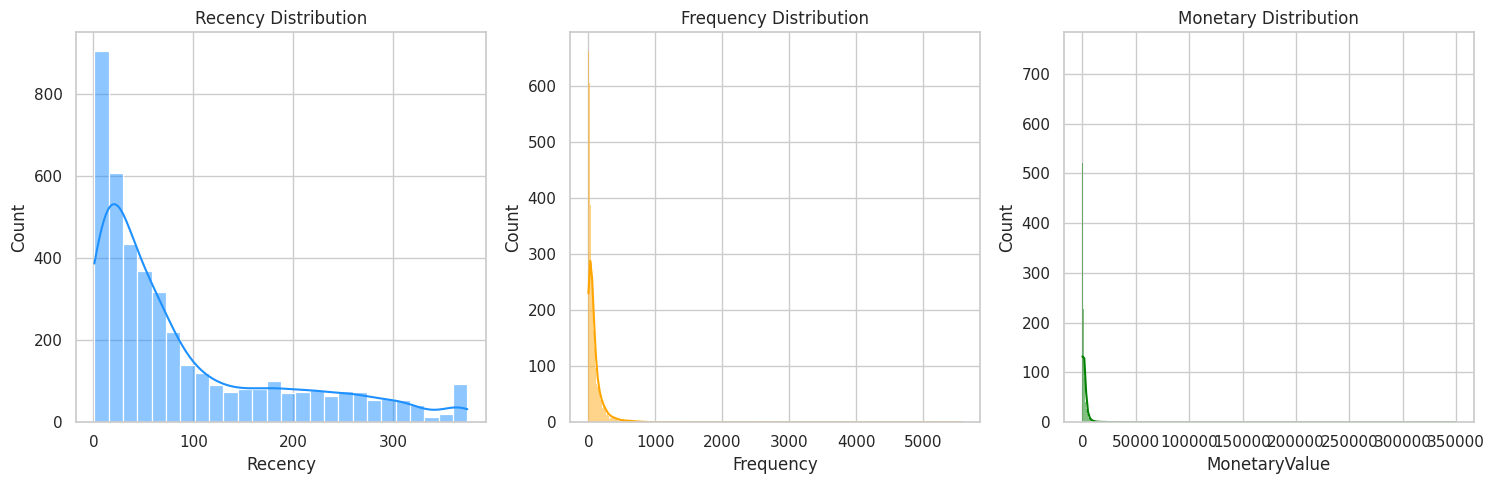

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

# 1. Distribution of Recency
plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True, color='dodgerblue')
plt.title('Recency Distribution')

# 2. Distribution of Frequency
plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], kde=True, color='orange')
plt.title('Frequency Distribution')

# 3. Distribution of Monetary Value
plt.subplot(1, 3, 3)
sns.histplot(rfm['MonetaryValue'], kde=True, color='green')
plt.title('Monetary Distribution')

plt.tight_layout()
plt.show()

/tmp/ipykernel_350/2962233640.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = rfm.groupby('R_Score')[['Frequency', 'MonetaryValue']].mean()


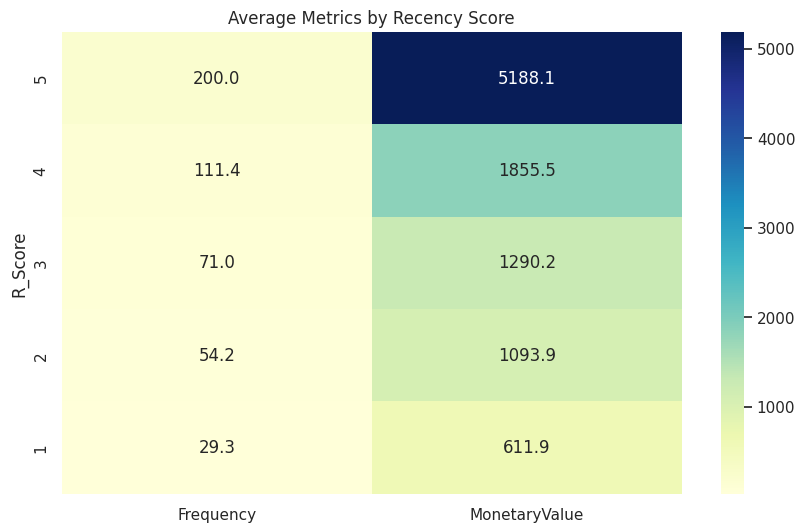

In [15]:
# Grouping by Segment to see average values
segment_analysis = rfm.groupby('R_Score')[['Frequency', 'MonetaryValue']].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(segment_analysis, annot=True, cmap="YlGnBu", fmt='.1f')
plt.title('Average Metrics by Recency Score')
plt.show()

In [16]:
# Example: Creating a prompt based on our Matplotlib insights
customer_data = "Customer ID 12345: Last bought 180 days ago, total spent $50."
prompt = f"Write a professional and friendly re-engagement email for this customer: {customer_data}"

# (Assuming you have your API key set up in Colab Secrets)
# response = model.generate_content(prompt)
# print(response.text)